In [247]:
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [46]:
# 1. 과제 1: Iris 3-class 분류
# 3개 붓꽃 종류 모두 분류하기 → LogisticRegression(multi_class='ovr')

In [47]:
iris = load_iris()

In [48]:
X = iris.data
y = iris.target

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [50]:
model = LogisticRegression(multi_class='ovr')

In [51]:
model.fit(X_train, y_train)

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


In [52]:
y_pred = model.predict(X_test)

In [65]:
y_proba = model.predict_proba(X_test) # y 값을 예측할 확률

In [66]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [81]:
print("="*60)
print(classification_report(y_test, y_pred,target_names=['setosa','versicolor','virginica']))
print("="*60)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



In [78]:
species = 0
species_name ='setosa'

y_test_number = (y_test == species )
y_proba_number = y_proba[:, species ]

auc = roc_auc_score(y_test_number, y_proba_number)

# 1.0일수록 좋고 0.5이하는 랜덤 수준이거나 그 이하
print("="*60)
print(f"{species_name}의 AUC : {auc}") 
print("="*60)

setosa의 AUC : 1.0


In [79]:
species = 1
species_name = 'versicolor'

y_test_number = (y_test == species )
y_proba_number = y_proba[:, species ]

auc = roc_auc_score(y_test_number, y_proba_number)

print("="*60)
print(f"{species_name}의 AUC : {auc}") 
print("="*60)

versicolor의 AUC : 1.0


In [80]:
species = 2

species_name ='virginica'

y_test_number = (y_test == species )
y_proba_number = y_proba[:, species]

auc = roc_auc_score(y_test_number, y_proba_number)

print("="*60)
print(f"{species_name}의 AUC : {auc}") 
print("="*60)

virginica의 AUC : 1.0


In [218]:
# 2. 타이타닉 생존률를 가지고 생존자 잘 분류해서 가장 높은 예측 점수 내오기
#  roc,auc score가 가장 높게

In [248]:
df = sns.load_dataset("titanic") 

In [249]:
df = df.dropna()
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [279]:
# 범주형 데이터 수치형으로 변환 해두기....어렵다...세상에나... 

label_cols = ['pclass', 'sex', 'embarked', 'class', 'adult_male']

for col in label_cols:
    le = LabelEncoder() # LabelEncoder : 문자형을 숫자로 바꿔주는 scikit learn객체
    df[col] = le.fit_transform(df[col].astype(str))  
    #df[col].astype(str) 칼럼을 문자로 통일
    # .fit_transform: fit(컬럼의 목록을 만들고) + transform (숫자로 바꿈)

In [280]:
X = df[['pclass', 'sex', 'age', 'fare','embarked','class','adult_male']]

In [281]:
X

,pclass,sex,age,fare,embarked,class,adult_male
1,0,0,38.0,71.2833,0,0,0
3,0,0,35.0,53.1000,2,0,0
6,0,1,54.0,51.8625,2,0,1
10,2,0,4.0,16.7000,2,2,0
11,0,0,58.0,26.5500,2,0,0
...,...,...,...,...,...,...,...
871,0,0,47.0,52.5542,2,0,0
872,0,1,33.0,5.0000,2,0,1
879,0,0,56.0,83.1583,0,0,0
887,0,0,19.0,30.0000,2,0,0


In [282]:
y = df_t['survived']

In [283]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [284]:
model = LogisticRegression()

In [285]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [286]:
y_pred = model.predict(X_test)

In [287]:
y_proba = model.predict_proba(X_test)

In [288]:
accuracy_score(y_test, y_pred) # 정확도

0.6486486486486487

In [289]:
FPR, TPR, threshold = roc_curve(y_test, y_proba[:,1]) # 성능곡선
auc_score = roc_auc_score(y_test, y_proba[:,1]) #곡선 아래 면적
print("="*60)
print(f" AUC : {auc_score}") 
print("="*60)

 AUC : 0.7403846153846153


In [290]:
print("="*60)
print(classification_report(y_test, y_pred, target_names=["survived","Dead"]))
print("="*60)

              precision    recall  f1-score   support

    survived       0.50      0.46      0.48        13
        Dead       0.72      0.75      0.73        24

    accuracy                           0.65        37
   macro avg       0.61      0.61      0.61        37
weighted avg       0.64      0.65      0.65        37



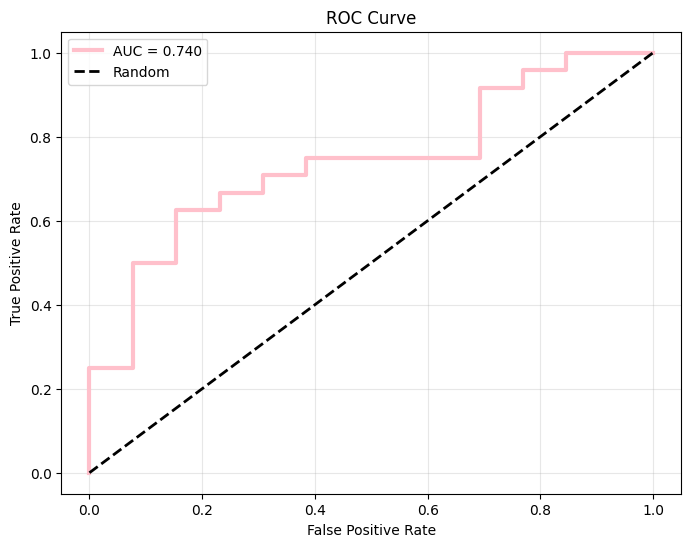

In [291]:
plt.figure(figsize=(8, 6))
plt.plot(FPR, TPR, linewidth=3, label=f'AUC = {auc_score:.3f}', color='pink')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()